In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# Load pre-processed dataset (mutations and expression)
full_dataset = ad.read_h5ad('combined_data.h5ad')

,count
survival_3yr_label,
0.0,134
1.0,112


<Axes: xlabel='survival_3yr_label', ylabel='count'>

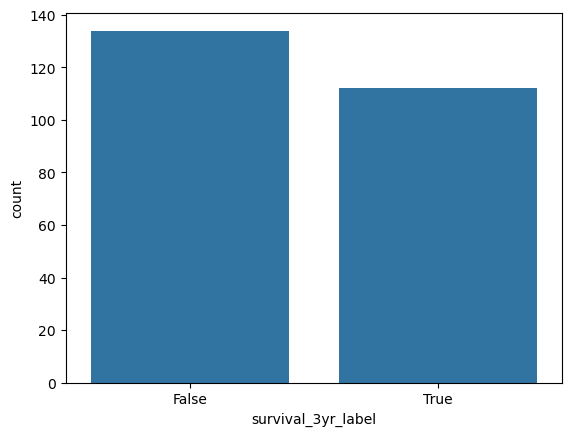

In [72]:
# Visualize distribution of survival labels
survival = pd.DataFrame(full_dataset.obs.value_counts(dropna=False)).reset_index()
survival['survival_3yr_label'] = survival['survival_3yr_label'].replace({1: True, 0: False})

sns.barplot(survival, x='survival_3yr_label', y='count')


In [57]:
# Concatenate features together to form full feature dataset
print(full_dataset.var['KM_markers'].value_counts())
print(full_dataset.var['jm_full_genes'].value_counts())
print(full_dataset.var['jm_colinear_genes'].value_counts())
print(full_dataset.var['jm_intersect_genes'].value_counts())
full_dataset.var

KM_markers
True     589
False    325
Name: count, dtype: int64
jm_full_genes
False    513
True     401
Name: count, dtype: int64
jm_colinear_genes
False    769
True     145
Name: count, dtype: int64
jm_intersect_genes
False    896
True      18
Name: count, dtype: int64


,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,KM_markers,jm_full_genes,jm_colinear_genes,jm_intersect_genes
RRM2,2861.806576,9.364733e+06,4.051495e+06,2.311426,False,False,True,False,False
MAP3K19,106.224371,6.139978e+04,2.431814e+04,2.524856,False,True,False,False,False
USP43,567.856867,1.921920e+05,2.840960e+05,0.676504,False,True,False,False,False
PIK3C2B,2146.237911,3.491429e+06,2.381328e+06,1.466169,False,False,True,False,False
PRB4,46.516441,2.396530e+05,5.579231e+03,4.885478,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...
MYT1L,15.203095,9.581782e+03,7.117246e+02,6.908280,True,True,False,False,False
GALNS,1515.736944,9.706562e+05,1.292618e+06,0.750923,False,True,False,False,False
ACOT4,320.212766,6.589348e+04,1.303930e+05,0.505345,False,True,False,False,False
SPTB,1501.460348,7.039655e+06,1.271893e+06,5.534784,True,False,True,False,False


In [74]:
# Create full dataset with counts/expression and mutations

# Load mutation features
full_mutation = pd.read_csv('/Users/aleyshachen/BENG_285/proj_5/full_union_patient_gene_matrix.csv', index_col=0)
full_mutation_feat = full_mutation.copy()
full_mutation_feat.columns = full_mutation.columns + "_mut"
# Create a boolean mask for the genes you want to keep
# gene_mask = full_dataset.var['jm_full_genes'] == True

# Subset columns (genes) using the mask
# dataset_fullmut = full_dataset[:, gene_mask]
# dataset_fullmut = full_dataset[full_dataset.var['jm_full_genes'] == 'True']

# Load gene counts features
gene_counts = pd.DataFrame(full_dataset.X.todense())
gene_counts.index = full_mutation.index.tolist()
gene_counts.columns = full_dataset.var.index.tolist()
gene_counts.columns = gene_counts.columns + "_counts"

# Concatenate features for full feature set
full_feat = pd.concat([full_mutation_feat, gene_counts], axis=1)

In [77]:
full_feat

,ACAN_mut,ANK1_mut,ATM_mut,BCHE_mut,BCORL1_mut,CACNA1C_mut,CCBE1_mut,CSMD1_mut,DOCK7_mut,DST_mut,...,SMAD4_counts,PRDX6_counts,SARDH_counts,TMEM107_counts,NR1I2_counts,MYT1L_counts,GALNS_counts,ACOT4_counts,SPTB_counts,FAT4_counts
TCGA-05-4244,1,1,1,1,1,1,1,1,2,1,...,0.502378,1.385320,0.059364,0.070122,0.000943,0.005331,0.143850,0.118896,1.230384,0.123770
TCGA-05-4249,0,0,0,0,0,0,0,0,0,0,...,0.631668,1.197734,0.073998,0.051177,0.000940,0.000000,0.317948,0.028433,0.229897,0.181281
TCGA-05-4250,0,0,0,0,0,0,0,1,0,0,...,0.471347,1.135639,0.049376,0.109029,0.011987,0.000317,0.207072,0.088763,0.175358,0.116541
TCGA-05-4382,0,0,1,0,0,0,0,0,0,2,...,0.533681,0.950660,0.035555,0.147445,0.005430,0.125651,0.445982,0.118943,0.038024,0.116285
TCGA-05-4384,0,0,0,0,0,0,0,0,0,1,...,0.601553,1.570049,0.050760,0.167416,0.001815,0.000000,0.238094,0.043250,0.220766,0.187193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-NJ-A55O,0,0,0,0,0,0,0,0,0,0,...,0.407820,1.017234,0.030328,0.085349,0.002017,0.000000,0.253865,0.054041,0.078372,0.149308
TCGA-NJ-A55R,0,0,0,0,0,0,0,0,0,1,...,0.437934,1.369385,0.056712,0.169923,0.007217,0.005518,0.431812,0.047640,0.471076,0.089809
TCGA-NJ-A7XG,0,0,0,0,0,0,0,0,0,0,...,0.516651,1.083553,0.026823,0.176080,0.001217,0.000000,0.167194,0.039189,0.112517,0.135988
TCGA-O1-A52J,1,0,0,1,0,0,0,0,0,0,...,0.254577,1.262180,0.027540,0.074387,0.003049,0.000436,0.388593,0.026053,0.704202,0.276324


Dataset shape: (246, 1326)
Number of classes: 2
Class distribution: [134 112]

Training set size: 196
Test set size: 50

Training the SVM model...

Model Performance:
Training Accuracy: 1.0000
Test Accuracy: 0.6600

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.71      0.63      0.67        27
         1.0       0.62      0.70      0.65        23

    accuracy                           0.66        50
   macro avg       0.66      0.66      0.66        50
weighted avg       0.67      0.66      0.66        50



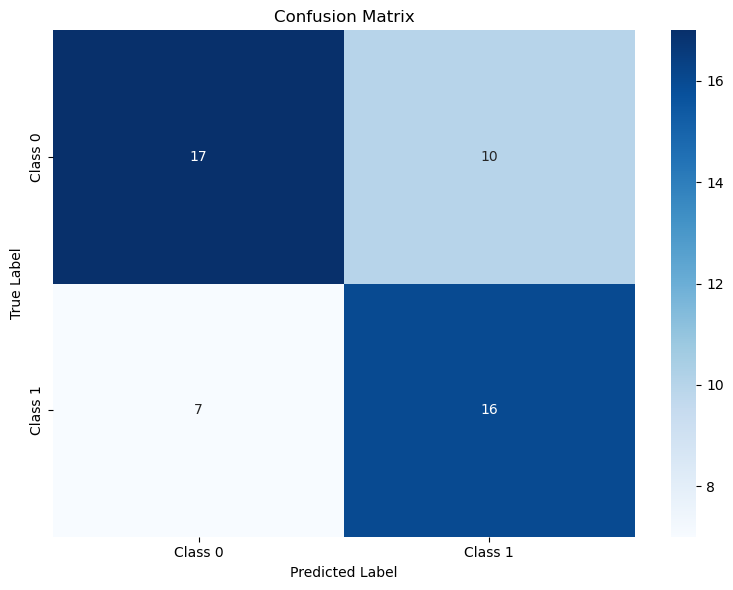


Model Parameters:
Number of iterations: 12
Final loss: hinge
Penalty: elasticnet
Alpha (regularization): 0.001
L1 ratio: 0.5
Top 5 features:  Index(['TCF12_mut', 'SLC3A1_counts', 'LGR6_counts', 'OTOGL_mut',
       'DNASE2B_counts'],
      dtype='object')


<Figure size 1200x600 with 0 Axes>

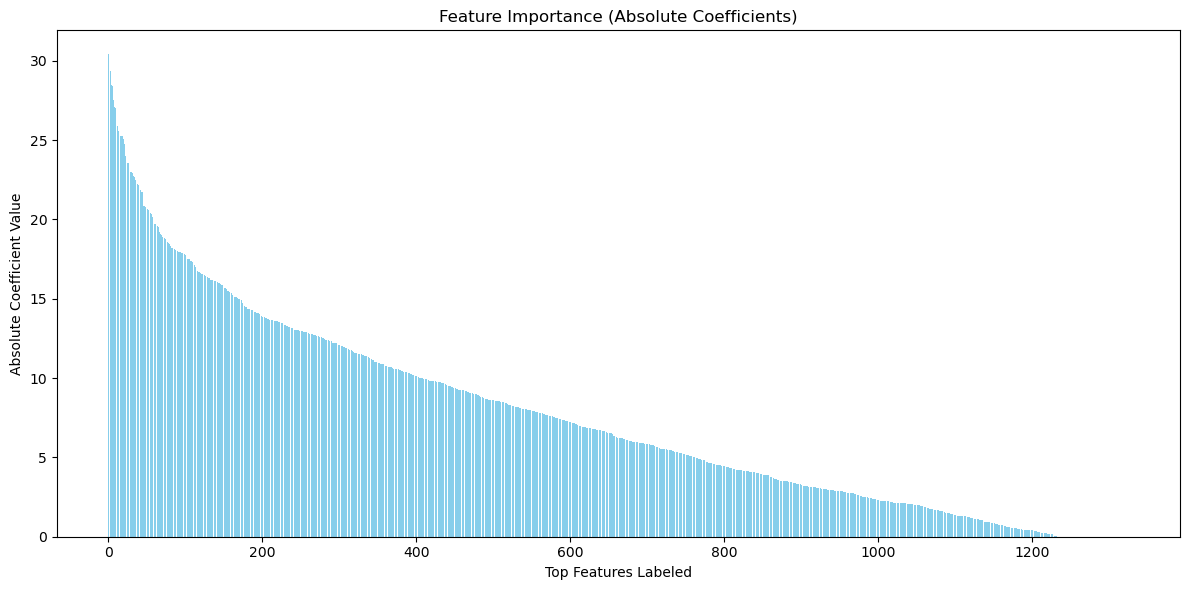

In [ ]:
# Split training vs. test data, train linear SVM using SGDClassifier (loss = 'hinge', penalty = 'elasticnet') [https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier]

# Drop samples that don't have survival labels and make sure X and y align
y = full_dataset.obs['survival_3yr_label'].dropna()
X =  full_feat[full_feat.index.isin(y.index)]

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensures balanced split across classes
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear SVM using SGDClassifier
# Substituted with best values from hyperparam tuning : 'alpha': 0.001, 'eta0': 0, 'l1_ratio': 0.5, 'learning_rate': 'optimal', 'warm_start': True
svm_model = SGDClassifier(
    loss='hinge',           # SVM loss function
    penalty='elasticnet',   # L1 + L2 regularization
    alpha=0.001,            # Regularization strength
    l1_ratio=0.5,          
    max_iter=1000,         
    tol=1e-3,              
    eta0=0,
    random_state=42,
    learning_rate='optimal',
    warm_start=True
)

# Fit the model
print("\nTraining the SVM model...")
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nModel Performance:")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Detailed classification report
print(f"\nDetailed Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Class {i}' for i in range(len(np.unique(y)))],
            yticklabels=[f'Class {i}' for i in range(len(np.unique(y)))])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Model parameters
print(f"\nModel Parameters:")
print(f"Number of iterations: {svm_model.n_iter_}")
print(f"Final loss: {svm_model.loss}")
print(f"Penalty: {svm_model.penalty}")
print(f"Alpha (regularization): {svm_model.alpha}")
print(f"L1 ratio: {svm_model.l1_ratio}")

# Feature importance (coefficients)
if hasattr(svm_model, 'coef_'):
    feature_importance = np.abs(svm_model.coef_[0])
    plt.figure(figsize=(12, 6))

    # Get feature names 
    feature_names = X.columns

    # Sort features by importance
    sorted_idx = np.argsort(feature_importance)[::-1]
    sorted_importance = feature_importance[sorted_idx]
    sorted_names = feature_names[sorted_idx]

    # How many top features to label
    top_n = 5

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(sorted_importance)), sorted_importance, color='skyblue')

    # Label only top N features
    # for i in range(top_n):
    #     plt.text(i, sorted_importance[i] + 0.01, sorted_names[i],
    #             ha='center', va='bottom', rotation=90, fontsize=9, fontweight='bold')

    # Print top 5 features
    print("Top 5 features: ", sorted_names[:5])

    plt.title('Feature Importance (Absolute Coefficients)')
    plt.xlabel('Top Features Labeled')
    plt.ylabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()

In [85]:
# Use GridSearchCV for hyperparam tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.15, 0.5, 0.85],
    'learning_rate': ['constant', 'optimal', 'adaptive'],
    'eta0': [0, 0.0001, 0.001, 0.01],
    'warm_start': [True, False]
}

grid_search = GridSearchCV(
    SGDClassifier(loss='hinge', penalty='elasticnet', max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Test the best model
best_model = grid_search.best_estimator_
best_test_accuracy = best_model.score(X_test_scaled, y_test)
print(f"Best model test accuracy: {best_test_accuracy:.4f}")

Best parameters: {'alpha': 0.001, 'eta0': 0, 'l1_ratio': 0.5, 'learning_rate': 'optimal', 'warm_start': True}
Best cross-validation score: 0.6735
Best model test accuracy: 0.6600


/opt/anaconda3/envs/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
240 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/jupyter-env/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/envs/jupyter-env/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/jupyter-env/lib/python3.12/site-p